# Automated Essay Scoring — Full Modelling Pipeline

## Pipeline Overview
1. Load & clean training data  
2. Feature engineering (structural + TF-IDF + readability)  
3. **Stratified train / validation split (80 / 20)**  
4. Fit preprocessors on train split only  
5. Model comparison on held-out validation set (QWK)  
6. Hyperparameter tuning (all models)  
7. Final model selection & retrain on full labelled data  
8. Generate predictions on unlabelled test set  
9. Export predictions CSV + model pickle  

## 1. Imports

In [1]:
import sys, re, os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split, RandomizedSearchCV
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

import lightgbm as lgb
import textstat

print(f'Python : {sys.version}')
print(f'NumPy  : {np.__version__}  |  Pandas: {pd.__version__}')

Python : 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
NumPy  : 2.1.3  |  Pandas: 2.2.3


## 2. Paths

Update `BASE` to your project folder. All other paths are derived from it automatically.

In [2]:
BASE      = Path(r"C:/Users/anand/Documents/Automated_essay_scoring")
RAW       = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
EXPORT    = BASE / "data" / "model"

TRAIN_FILE = RAW / "train.csv"
TEST_FILE  = RAW / "test.csv"          # unlabelled — essay_id + full_text only
PRED_FILE  = PROCESSED / "test_predictions.csv"
MODEL_FILE = EXPORT / "aes_model.pkl"

PROCESSED.mkdir(parents=True, exist_ok=True)
EXPORT.mkdir(parents=True, exist_ok=True)

print("Paths configured:")
for name, p in [("Train", TRAIN_FILE), ("Test", TEST_FILE),
                ("Predictions", PRED_FILE), ("Model", MODEL_FILE)]:
    print(f"  {name:<14}: {p}")

Paths configured:
  Train         : C:\Users\anand\Documents\Automated_essay_scoring\data\raw\train.csv
  Test          : C:\Users\anand\Documents\Automated_essay_scoring\data\raw\test.csv
  Predictions   : C:\Users\anand\Documents\Automated_essay_scoring\data\processed\test_predictions.csv
  Model         : C:\Users\anand\Documents\Automated_essay_scoring\data\model\aes_model.pkl


## 3. Load Data

In [3]:
train_raw = pd.read_csv(TRAIN_FILE)
test_raw  = pd.read_csv(TEST_FILE)

print(f'Labelled train : {train_raw.shape}')
print(f'Unlabelled test: {test_raw.shape}')
print(f'Score range    : {train_raw["score"].min()} – {train_raw["score"].max()}')
train_raw.head(3)

Labelled train : (17307, 3)
Unlabelled test: (3, 2)
Score range    : 1 – 6


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4


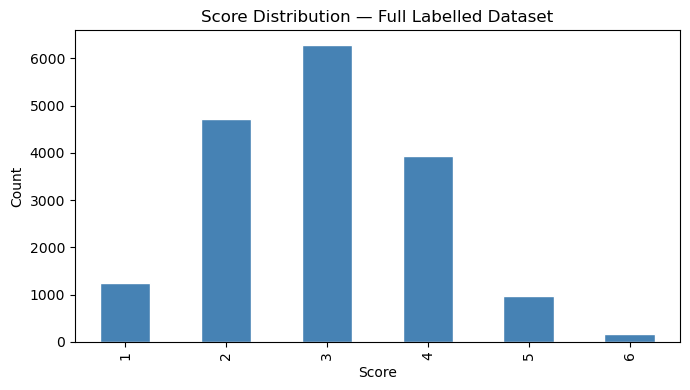

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
train_raw['score'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Score Distribution — Full Labelled Dataset')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## 4. Text Cleaning

In [5]:
def clean_text(text: str) -> str:
    """Normalise essay text for TF-IDF vectorisation."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_raw['clean_text'] = train_raw['full_text'].apply(clean_text)
test_raw['clean_text']  = test_raw['full_text'].apply(clean_text)
print('Cleaning done.')

Cleaning done.


## 5. Feature Engineering

In [6]:
def sentence_count(text: str) -> int:
    if not isinstance(text, str) or not text.strip():
        return 0
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return len([s for s in sentences if s])

def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """Extract structural and readability features."""
    feat = pd.DataFrame(index=df.index)

    feat['essay_length']    = df['full_text'].apply(len)
    feat['word_count']      = df['full_text'].apply(lambda x: len(x.split()))
    feat['sentence_count']  = df['full_text'].apply(sentence_count)
    feat['paragraph_count'] = df['full_text'].apply(
        lambda x: max(1, len([p for p in x.split('\n') if p.strip()]))
    )
    feat['avg_word_length'] = df['full_text'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    feat['avg_sentence_length'] = feat.apply(
        lambda r: r['word_count'] / r['sentence_count'] if r['sentence_count'] > 0 else 0,
        axis=1
    )
    feat['avg_paragraph_length'] = feat.apply(
        lambda r: r['word_count'] / r['paragraph_count'] if r['paragraph_count'] > 0 else 0,
        axis=1
    )
    feat['unique_word_ratio'] = df['clean_text'].apply(
        lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
    )


    feat['flesch_kincaid_grade'] = df['full_text'].apply(textstat.flesch_kincaid_grade)
    feat['flesch_reading_ease']  = df['full_text'].apply(textstat.flesch_reading_ease)
    feat['gunning_fog']          = df['full_text'].apply(textstat.gunning_fog)

    return feat

all_feat  = extract_features(train_raw)
test_feat = extract_features(test_raw)
print(f'Features extracted: {all_feat.shape[1]} columns')
all_feat.describe()

Features extracted: 11 columns


,essay_length,word_count,sentence_count,paragraph_count,avg_word_length,avg_sentence_length,avg_paragraph_length,unique_word_ratio,flesch_kincaid_grade,flesch_reading_ease,gunning_fog
count,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000
mean,2071.617265,368.348241,18.504709,4.965332,4.536643,22.509867,89.812647,0.477053,9.556649,63.205308,11.884462
std,925.910701,150.394776,8.431053,3.311649,0.310465,16.290681,55.255505,0.075685,5.269797,15.874601,5.403141
min,712.000000,150.000000,1.000000,1.000000,3.441948,7.400000,4.560606,0.053744,1.716888,-632.715455,4.115965
25%,1397.000000,253.000000,12.000000,3.000000,4.320967,16.529412,60.500000,0.423379,7.494006,56.358991,9.736046
50%,1924.000000,345.000000,18.000000,5.000000,4.534527,19.769231,78.600000,0.473510,9.037044,64.164893,11.342697
75%,2541.000000,452.000000,24.000000,5.000000,4.750988,24.277778,102.400000,0.528012,10.759415,71.610937,13.151357
max,20459.000000,1656.000000,91.000000,66.000000,5.877500,715.000000,1656.000000,0.746914,279.136364,100.818873,288.573427


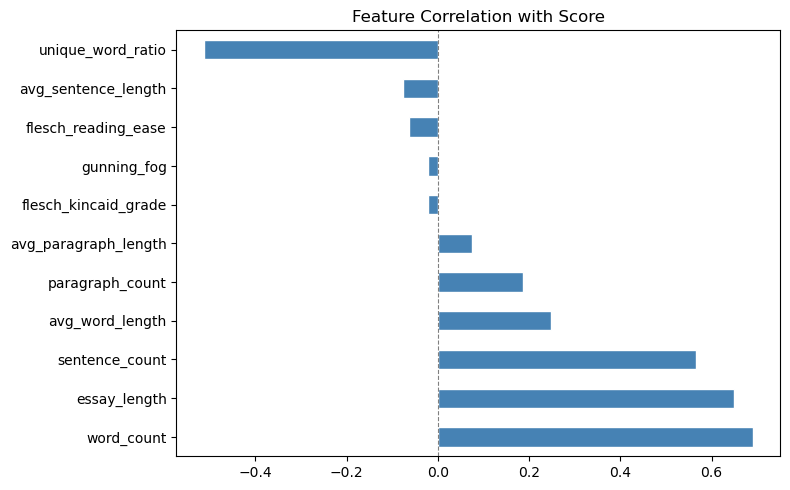

In [7]:
corr_df = all_feat.copy()
corr_df['score'] = train_raw['score'].values
correlations = corr_df.corr()['score'].drop('score').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Correlation with Score')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()

In [8]:
# # Drop columns
# all_feat = all_feat.drop(['avg_paragraph_length', 'flesch_reading_ease','paragraph_count'], axis=1)

# # Preview
# all_feat.head()

In [9]:
# # Drop columns
# test_feat = test_feat.drop(['avg_paragraph_length', 'flesch_reading_ease','paragraph_count'], axis=1)

# # Preview
# test_feat.head()

## 6. Train / Validation Split (80 / 20, Stratified)

We hold out 20 % of the labelled data as a **true validation set**. Preprocessors (TF-IDF, scaler) are fit **only on the 80 % training split** to avoid leakage.

In [10]:
RANDOM_STATE = 42
VAL_SIZE     = 0.20

train_df, val_df = train_test_split(
    train_raw,
    test_size=VAL_SIZE,
    stratify=train_raw['score'],
    random_state=RANDOM_STATE
)

# Align feature rows to the split indices
train_feat = all_feat.loc[train_df.index]
val_feat   = all_feat.loc[val_df.index]

print(f'Train split : {train_df.shape[0]} rows  ({1-VAL_SIZE:.0%})')
print(f'Val   split : {val_df.shape[0]} rows  ({VAL_SIZE:.0%})')
print()
print('Score distribution — train split:')
print(train_df['score'].value_counts().sort_index().to_dict())
print('Score distribution — val split:')
print(val_df['score'].value_counts().sort_index().to_dict())

Train split : 13845 rows  (80%)
Val   split : 3462 rows  (20%)

Score distribution — train split:
{1: 1001, 2: 3778, 3: 5024, 4: 3141, 5: 776, 6: 125}
Score distribution — val split:
{1: 251, 2: 945, 3: 1256, 4: 785, 5: 194, 6: 31}


## 7. Build Feature Matrices

Fit TF-IDF and StandardScaler on the **train split only**, then transform val and test.

In [11]:
# TF-IDF — fit on train split only
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
)
X_tr_tfidf  = vectorizer.fit_transform(train_df['clean_text'])
X_val_tfidf = vectorizer.transform(val_df['clean_text'])
X_te_tfidf  = vectorizer.transform(test_raw['clean_text'])

print(f'TF-IDF shapes  train={X_tr_tfidf.shape}  val={X_val_tfidf.shape}  test={X_te_tfidf.shape}')

# Structural scaler — fit on train split only
scaler = StandardScaler()
X_tr_struct  = csr_matrix(scaler.fit_transform(train_feat.fillna(0)))
X_val_struct = csr_matrix(scaler.transform(val_feat.fillna(0)))
X_te_struct  = csr_matrix(scaler.transform(test_feat.fillna(0)))

# Combine
X_train = hstack([X_tr_tfidf,  X_tr_struct])
X_val   = hstack([X_val_tfidf, X_val_struct])
X_test  = hstack([X_te_tfidf,  X_te_struct])

y_train = train_df['score'].values
y_val   = val_df['score'].values

print(f'\nFinal shapes   train={X_train.shape}  val={X_val.shape}  test={X_test.shape}')

TF-IDF shapes  train=(13845, 5000)  val=(3462, 5000)  test=(3, 5000)

Final shapes   train=(13845, 5011)  val=(3462, 5011)  test=(3, 5011)


## 8. Evaluation Helper

In [12]:
def qwk_score(y_true, y_pred):
    """QWK scorer — rounds regression outputs before scoring."""
    y_pred_clipped = np.clip(np.round(y_pred).astype(int), 1, 6)
    return cohen_kappa_score(y_true, y_pred_clipped, weights='quadratic')

qwk_scorer = make_scorer(qwk_score)

def eval_on_val(model, X_val, y_val, name="model"):
    """Predict on validation set and print QWK + confusion matrix."""
    raw = model.predict(X_val)
    if hasattr(model, 'coef_') and not hasattr(model, 'classes_'):
        preds = np.clip(np.round(raw).astype(int), 1, 6)
    else:
        preds = raw.astype(int)

    qwk = qwk_score(y_val, preds)
    print(f"[{name}]  Val QWK = {qwk:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_val, preds, labels=[1,2,3,4,5,6])
    disp = ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5,6])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}  (QWK={qwk:.4f})')
    plt.tight_layout(); plt.show()
    return qwk, preds

## 9. Model Comparison on Validation Set

All models are trained on the **train split** and evaluated on the **held-out val split**. No cross-validation leakage.


 Training: Ridge (regression)
[Ridge (regression)]  Val QWK = 0.7629


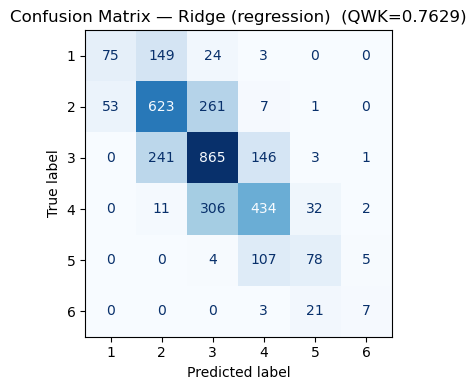


 Training: RidgeClassifier
[RidgeClassifier]  Val QWK = 0.6361


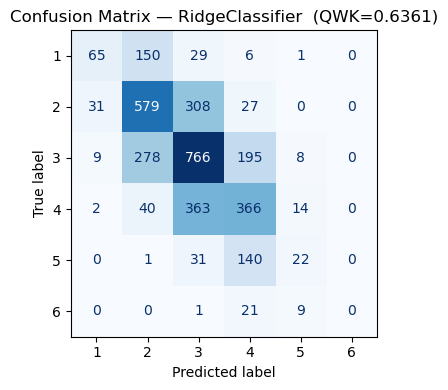


 Training: Random Forest
[Random Forest]  Val QWK = 0.6552


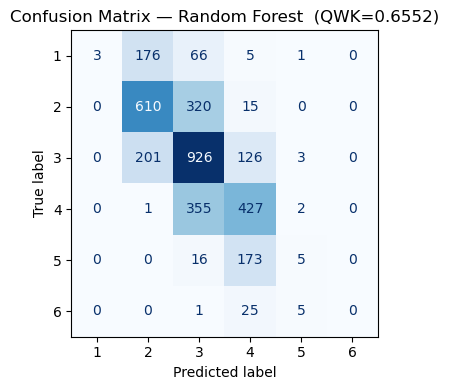


 Training: LightGBM
[LightGBM]  Val QWK = 0.7570


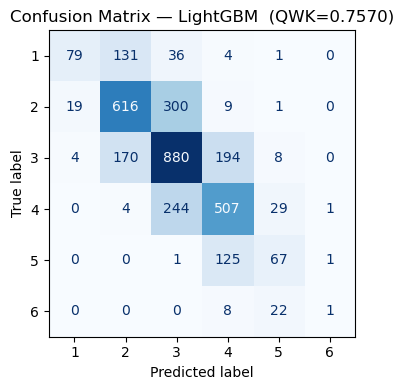

In [13]:
candidates = {
    'Ridge (regression)': Ridge(alpha=1.0),
    'RidgeClassifier':    RidgeClassifier(alpha=1.0),
    'Random Forest':      RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
}

val_results = {}

for name, model in candidates.items():
    print(f"\n{'='*55}")
    print(f" Training: {name}")
    print('='*55)
    model.fit(X_train, y_train)
    qwk, preds = eval_on_val(model, X_val, y_val, name)
    val_results[name] = {'model': model, 'qwk': qwk, 'preds': preds}

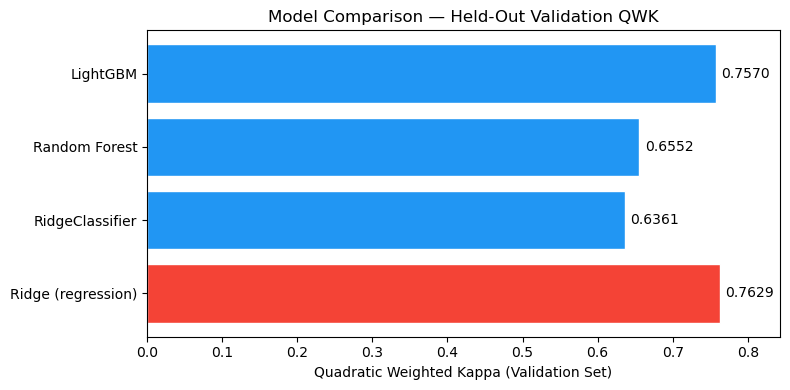


 Best model: Ridge (regression)  (QWK = 0.7629)


In [14]:
# Summary bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(val_results.keys())
scores = [val_results[n]['qwk'] for n in names]
colors = ['#2196F3' if s < max(scores) else '#F44336' for s in scores]
bars = ax.barh(names, scores, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlabel('Quadratic Weighted Kappa (Validation Set)')
ax.set_title('Model Comparison — Held-Out Validation QWK')
ax.set_xlim(0, min(1.0, max(scores) + 0.08))
plt.tight_layout(); plt.show()

best_name = max(val_results, key=lambda n: val_results[n]['qwk'])
print(f"\n Best model: {best_name}  (QWK = {val_results[best_name]['qwk']:.4f})")

## 10. Hyperparameter Tuning

Tune each model using 5-fold CV **on the train split**. Validation set is not touched during tuning.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_results = {}

Tuning Ridge...
  Best alpha : 1.0
  CV QWK     : 0.7726
[Tuned Ridge]  Val QWK = 0.7629


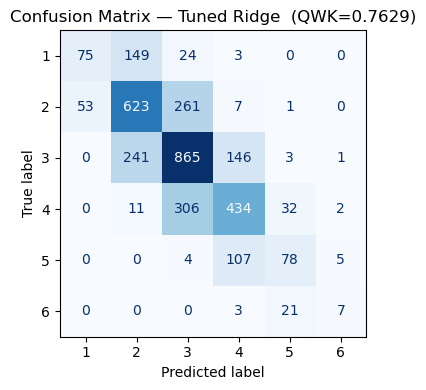

In [16]:
# ── Ridge alpha search ──────────────────────────────────────────────────────
print("Tuning Ridge...")
ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions={'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]},
    n_iter=8, cv=cv, scoring=qwk_scorer, n_jobs=-1, random_state=RANDOM_STATE
)
ridge_search.fit(X_train, y_train)
print(f"  Best alpha : {ridge_search.best_params_['alpha']}")
print(f"  CV QWK     : {ridge_search.best_score_:.4f}")

tuned_ridge = ridge_search.best_estimator_
qwk_r, _   = eval_on_val(tuned_ridge, X_val, y_val, "Tuned Ridge")
tuned_results['Tuned Ridge'] = {'model': tuned_ridge, 'qwk': qwk_r}

Tuning RidgeClassifier...
  Best alpha : 10.0
  CV QWK     : 0.6550
[Tuned RidgeClassifier]  Val QWK = 0.6576


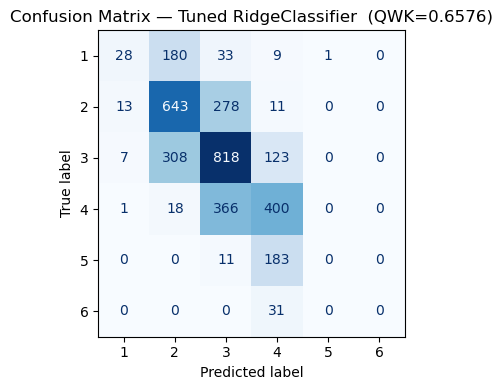

In [17]:
# ── RidgeClassifier alpha search ────────────────────────────────────────────
print("Tuning RidgeClassifier...")
rc_search = RandomizedSearchCV(
    RidgeClassifier(),
    param_distributions={'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]},
    n_iter=8, cv=cv, scoring=qwk_scorer, n_jobs=-1, random_state=RANDOM_STATE
)
rc_search.fit(X_train, y_train)
print(f"  Best alpha : {rc_search.best_params_['alpha']}")
print(f"  CV QWK     : {rc_search.best_score_:.4f}")

tuned_rc  = rc_search.best_estimator_
qwk_rc, _ = eval_on_val(tuned_rc, X_val, y_val, "Tuned RidgeClassifier")
tuned_results['Tuned RidgeClassifier'] = {'model': tuned_rc, 'qwk': qwk_rc}

In [18]:
# # ── LightGBM search ─────────────────────────────────────────────────────────
# print("Tuning LightGBM...")
# lgb_search = RandomizedSearchCV(
#     lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
#     param_distributions={
#         'n_estimators':      [300, 500, 800],
#         'learning_rate':     [0.01, 0.05, 0.1],
#         'num_leaves':        [31, 63, 127],
#         'max_depth':         [-1, 6, 10],
#         'min_child_samples': [10, 20, 50],
#         'subsample':         [0.7, 0.85, 1.0],
#         'colsample_bytree':  [0.7, 0.85, 1.0],
#     },
#     n_iter=30, cv=cv, scoring=qwk_scorer, n_jobs=-1, random_state=RANDOM_STATE
# )
# lgb_search.fit(X_train, y_train)
# print(f"  Best params: {lgb_search.best_params_}")
# print(f"  CV QWK     : {lgb_search.best_score_:.4f}")

# tuned_lgb  = lgb_search.best_estimator_
# qwk_lgb, _ = eval_on_val(tuned_lgb, X_val, y_val, "Tuned LightGBM")
# tuned_results['Tuned LightGBM'] = {'model': tuned_lgb, 'qwk': qwk_lgb}

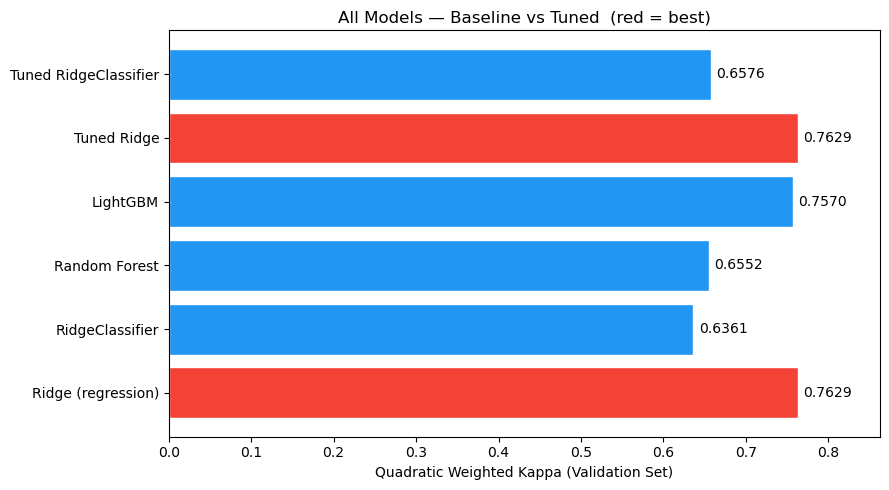


 Winner: Ridge (regression)  (Val QWK = 0.7629)


In [19]:
# Tuning summary
fig, ax = plt.subplots(figsize=(9, 5))
all_r = {**{n: val_results[n]['qwk'] for n in val_results},
         **{n: tuned_results[n]['qwk'] for n in tuned_results}}
names_all  = list(all_r.keys())
scores_all = list(all_r.values())
best_score = max(scores_all)
colors_all = ['#F44336' if s == best_score else '#2196F3' for s in scores_all]
bars = ax.barh(names_all, scores_all, color=colors_all, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlabel('Quadratic Weighted Kappa (Validation Set)')
ax.set_title('All Models — Baseline vs Tuned  (red = best)')
ax.set_xlim(0, min(1.0, best_score + 0.10))
plt.tight_layout(); plt.show()

winner_name = max(all_r, key=all_r.get)
winner_model = (tuned_results if winner_name in tuned_results else val_results)[winner_name]['model']
print(f"\n Winner: {winner_name}  (Val QWK = {all_r[winner_name]:.4f})")

## 11. Retrain Best Model on Full Labelled Data

Once the model is selected, re-fit the preprocessors and model on **all 17 k labelled rows** to maximise the information going into the final predictions.

In [20]:
print("Re-fitting preprocessors on full labelled dataset...")

vectorizer_final = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=3, strip_accents='unicode',
)
scaler_final = StandardScaler()

X_full_tfidf  = vectorizer_final.fit_transform(train_raw['clean_text'])
X_full_struct = csr_matrix(scaler_final.fit_transform(all_feat.fillna(0)))
X_full        = hstack([X_full_tfidf, X_full_struct])
y_full        = train_raw['score'].values

# Clone best model config and retrain
import copy
final_model = copy.deepcopy(winner_model)
final_model.fit(X_full, y_full)
print(f"Final model ({winner_name}) retrained on {X_full.shape[0]} samples.")

Re-fitting preprocessors on full labelled dataset...
Final model (Ridge (regression)) retrained on 17307 samples.


## 12. Generate Test Predictions

In [21]:
X_test_final_tfidf  = vectorizer_final.transform(test_raw['clean_text'])
X_test_final_struct = csr_matrix(scaler_final.transform(test_feat.fillna(0)))
X_test_final        = hstack([X_test_final_tfidf, X_test_final_struct])

raw_preds = final_model.predict(X_test_final)

if hasattr(final_model, 'coef_') and not hasattr(final_model, 'classes_'):
    predictions = np.clip(np.round(raw_preds).astype(int), 1, 6)
else:
    predictions = raw_preds.astype(int)

submission = pd.DataFrame({'essay_id': test_raw['essay_id'], 'score': predictions})
display(submission)
print(f'\nPrediction distribution:')
print(submission['score'].value_counts().sort_index())

,essay_id,score
0,000d118,2
1,000fe60,3
2,001ab80,4



Prediction distribution:
score
2    1
3    1
4    1
Name: count, dtype: int64


## 13. Export Predictions & Model Bundle

In [22]:
submission.to_csv(PRED_FILE, index=False)
print(f'Predictions saved → {PRED_FILE}')

model_bundle = {
    'model':      final_model,
    'vectorizer': vectorizer_final,
    'scaler':     scaler_final,
    'model_name': winner_name,
}
with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model_bundle, f)
print(f'Model bundle saved → {MODEL_FILE}')
print(f'Bundle keys: {list(model_bundle.keys())}')

Predictions saved → C:\Users\anand\Documents\Automated_essay_scoring\data\processed\test_predictions.csv
Model bundle saved → C:\Users\anand\Documents\Automated_essay_scoring\data\model\aes_model.pkl
Bundle keys: ['model', 'vectorizer', 'scaler', 'model_name']


## 14. Inference Helper

Use this to score a new essay without re-running the whole pipeline.

In [23]:
def predict_essay_score(essay_text: str, bundle: dict) -> int:
    """
    Score a single essay using the saved model bundle.

    Parameters
    ----------
    essay_text : str  — raw essay text
    bundle     : dict — loaded pickle with keys: model, vectorizer, scaler

    Returns
    -------
    int — predicted score (1–6)
    """
    model      = bundle['model']
    vectorizer = bundle['vectorizer']
    scaler     = bundle['scaler']

    row = pd.DataFrame({'full_text': [essay_text]})
    row['clean_text'] = row['full_text'].apply(clean_text)

    tfidf_vec   = vectorizer.transform(row['clean_text'])
    struct_feat = extract_features(row).fillna(0)
    struct_vec  = csr_matrix(scaler.transform(struct_feat))

    X   = hstack([tfidf_vec, struct_vec])
    raw = model.predict(X)[0]

    if isinstance(raw, float):
        return int(np.clip(round(raw), 1, 6))
    return int(raw)


# ── Quick sanity check ──────────────────────────────────────────────────────
bundle_loaded = pickle.load(open(MODEL_FILE, 'rb'))
print(f"Loaded model: {bundle_loaded['model_name']}")

for idx in range(min(5, len(train_raw))):
    sample = train_raw['full_text'].iloc[idx]
    true   = train_raw['score'].iloc[idx]
    pred   = predict_essay_score(sample, bundle_loaded)
    match  = "✓" if true == pred else "✗"
    print(f"  Essay {idx+1}:  true={true}  pred={pred}  {match}")

Loaded model: Ridge (regression)
  Essay 1:  true=3  pred=2  ✗
  Essay 2:  true=3  pred=3  ✓
  Essay 3:  true=4  pred=4  ✓
  Essay 4:  true=4  pred=4  ✓
  Essay 5:  true=3  pred=2  ✗
